# Code Concatenation with Steane-on-Steane

This notebook constructs a concatenated Steane code in the current `@logical.kernel` stack by using an **outer** `[[7,1,3]]` Steane code over 7 logical qubits. Each of those 7 logical qubits is then lowered by `GeminiLogicalSimulator` into its own inner Steane block, producing a `[[49,1,9]]` concatenated code at the physical-measurement level.

A subtle but important point: this is **not** recursive lowering of an already-lowered squin kernel back into a new logical kernel. The current stack does not expose that as a first-class user workflow. Instead, we use the supported path: one outer logical kernel plus custom `m2dets`/`m2obs` matrices that interpret the final 49 physical measurements as inner and outer Steane syndromes and observables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag

from bloqade import qubit, squin
from bloqade.gemini import logical
from bloqade.lanes import GeminiLogicalSimulator
from bloqade.decoders import BpOsdDecoder

In [2]:
STEANE_H = np.array(
    [
        [1, 1, 1, 1, 0, 0, 0],
        [0, 1, 1, 0, 1, 1, 0],
        [0, 0, 1, 1, 1, 0, 1],
    ],
    dtype=int,
)

# Logical Z support used by the current Steane default post-processing path.
STEANE_OBS = np.array([[1, 1, 0, 0, 0, 1, 0]], dtype=int)


def concatenated_steane_matrices():
    """Return measurement-to-detector / measurement-to-observable matrices for
    Steane-on-Steane concatenation.

    The 49 final physical measurements are grouped into 7 inner Steane blocks.
    We expose:
    - 21 inner detectors (3 per inner block)
    - 3 outer detectors, built from the 7 inner logical bits
    - 1 outer observable
    """
    inner_det = np.asarray(block_diag(*[STEANE_H.T] * 7), dtype=int)   # (49, 21)
    inner_obs = np.asarray(block_diag(*[STEANE_OBS.T] * 7), dtype=int) # (49, 7)

    outer_det = (inner_obs @ STEANE_H.T) % 2   # (49, 3)
    outer_obs = (inner_obs @ STEANE_OBS.T) % 2 # (49, 1)

    m2dets = np.concatenate([inner_det, outer_det], axis=1) % 2
    m2obs = outer_obs % 2
    return m2dets.tolist(), m2obs.tolist()


concat_m2dets, concat_m2obs = concatenated_steane_matrices()
print(np.asarray(concat_m2dets).shape, np.asarray(concat_m2obs).shape)

(49, 24) (49, 1)


## Outer logical kernel

This kernel acts on 7 **logical** qubits. The simulator then lowers each logical qubit to an inner Steane block. The circuit below prepares an outer encoded `|0_L>` using a standard Steane encoder pattern. Because the final observable is a logical Z readout, the noiseless target is deterministic.

In [3]:
from kirin.dialects import ilist

In [4]:
@logical.kernel(aggressive_unroll=True, verify=True)
def concatenated_steane_memory():
    q = qubit.qalloc(7)

    # Steane encoder: input |0> on q[6], with three |+> ancillas.
    squin.h(q[1])
    squin.h(q[2])
    squin.h(q[3])

    squin.cx(q[6], q[5])
    squin.cx(q[1], q[0])
    squin.cx(q[2], q[4])
    squin.cx(q[2], q[0])
    squin.cx(q[3], q[5])
    squin.cx(q[1], q[5])
    squin.cx(q[6], q[4])
    squin.cx(q[2], q[6])
    squin.cx(q[3], q[4])
    squin.cx(q[3], q[0])
    squin.cx(q[1], q[6])

    # The task layer will append terminal measurements and annotations from
    # concat_m2dets / concat_m2obs.
    return

In [5]:
sim = GeminiLogicalSimulator()
task = sim.task(
    concatenated_steane_memory,
    m2dets=concat_m2dets,
    m2obs=concat_m2obs,
)

shots = 4000
result = task.run(shots, with_noise=True)
result_ideal = task.run(256, with_noise=False)

measurements = np.asarray(result.measurements, dtype=bool)
detectors = np.asarray(result.detectors, dtype=bool)
observables = np.asarray(result.observables, dtype=bool)
ideal_observables = np.asarray(result_ideal.observables, dtype=bool)
target_obs = ideal_observables[0]

print('measurements shape:', measurements.shape)
print('detectors shape:   ', detectors.shape)
print('observables shape: ', observables.shape)
print('target observable: ', target_obs.astype(int).tolist())

measurements shape: (4000, 49)
detectors shape:    (4000, 24)
observables shape:  (4000, 1)
target observable:  [1]


In [ ]:
task.

In [6]:
task.tsim_circuit.diagram(height=400)

## Flat decoding from the detector error model

This is the simplest route: use the full detector error model produced by the concatenated construction, decode all detector bits at once, and correct the outer observable.

In [7]:
decoder = BpOsdDecoder(task.detector_error_model)
flat_flips = np.asarray(decoder.decode(detectors), dtype=bool)
flat_corrected = observables ^ flat_flips

raw_logical_error_rate = float(np.mean(np.any(observables != target_obs, axis=1)))
flat_decoded_error_rate = float(np.mean(np.any(flat_corrected != target_obs, axis=1)))

print('raw logical error rate:     ', raw_logical_error_rate)
print('flat decoded error rate:    ', flat_decoded_error_rate)

raw logical error rate:      0.4985
flat decoded error rate:     0.91825


## Hierarchical classical Steane decoding from the 49 raw measurements

This second route ignores the global detector error model and instead performs classical inner-block Steane decoding followed by outer-block Steane decoding. It is useful for seeing the concatenation structure directly.

In [8]:
def steane_syndrome_lookup():
    table = {}
    for qubit_idx in range(7):
        e = np.zeros(7, dtype=int)
        e[qubit_idx] = 1
        syndrome = tuple(((STEANE_H @ e) % 2).tolist())
        table[syndrome] = qubit_idx
    return table


STEANE_SYNDROME_TABLE = steane_syndrome_lookup()


def decode_steane_block(bits):
    corrected = bits.astype(np.bool_).copy()
    syndrome = (STEANE_H @ corrected.astype(int)) % 2
    key = tuple(map(int, syndrome.tolist()))
    if key != (0, 0, 0) and key in STEANE_SYNDROME_TABLE:
        corrected[STEANE_SYNDROME_TABLE[key]] ^= True
    logical_bit = ((STEANE_OBS @ corrected.astype(int)) % 2).astype(bool).reshape(1)
    return corrected, syndrome.astype(bool), logical_bit


def hierarchical_decode_concatenated_steane(raw_measurements):
    shots = raw_measurements.shape[0]
    reshaped = raw_measurements.reshape(shots, 7, 7)

    inner_corrected_bits = np.zeros((shots, 7, 7), dtype=bool)
    inner_syndromes = np.zeros((shots, 7, 3), dtype=bool)
    inner_logical_bits = np.zeros((shots, 7), dtype=bool)

    for shot in range(shots):
        for block in range(7):
            corrected, syndrome, logical_bit = decode_steane_block(reshaped[shot, block])
            inner_corrected_bits[shot, block] = corrected
            inner_syndromes[shot, block] = syndrome
            inner_logical_bits[shot, block] = logical_bit

    outer_corrected_bits = np.zeros((shots, 7), dtype=bool)
    outer_syndromes = np.zeros((shots, 3), dtype=bool)
    outer_logical_bit = np.zeros((shots, 1), dtype=bool)

    for shot in range(shots):
        corrected, syndrome, logical_bit = decode_steane_block(inner_logical_bits[shot])
        outer_corrected_bits[shot] = corrected
        outer_syndromes[shot] = syndrome
        outer_logical_bit[shot] = logical_bit

    return {
        'inner_corrected_bits': inner_corrected_bits,
        'inner_syndromes': inner_syndromes,
        'inner_logical_bits': inner_logical_bits,
        'outer_corrected_bits': outer_corrected_bits,
        'outer_syndromes': outer_syndromes,
        'outer_logical_bit': outer_logical_bit,
    }


hier = hierarchical_decode_concatenated_steane(measurements)
hier_corrected = hier['outer_logical_bit']
hier_decoded_error_rate = float(np.mean(np.any(hier_corrected != target_obs, axis=1)))

print('hierarchical decoded error rate:', hier_decoded_error_rate)

hierarchical decoded error rate: 0.5755


## Postselection

We show two postselection notions:

- **Full detector postselection:** keep only shots with no detector clicks at all.
- **Hierarchical postselection:** keep only shots with zero inner and zero outer Steane syndromes in the explicit blockwise decode.

In [9]:
full_postselect_mask = np.all(detectors == 0, axis=1)
full_postselected_obs = observables[full_postselect_mask]
full_postselection_rate = float(np.mean(full_postselect_mask))
full_postselected_error_rate = (
    float(np.mean(np.any(full_postselected_obs != target_obs, axis=1)))
    if len(full_postselected_obs) > 0
    else float('nan')
)

hier_postselect_mask = (
    np.all(hier['inner_syndromes'] == 0, axis=(1, 2))
    & np.all(hier['outer_syndromes'] == 0, axis=1)
)
hier_postselected_obs = hier_corrected[hier_postselect_mask]
hier_postselection_rate = float(np.mean(hier_postselect_mask))
hier_postselected_error_rate = (
    float(np.mean(np.any(hier_postselected_obs != target_obs, axis=1)))
    if len(hier_postselected_obs) > 0
    else float('nan')
)

summary = {
    'raw_logical_error_rate': raw_logical_error_rate,
    'flat_decoded_error_rate': flat_decoded_error_rate,
    'hierarchical_decoded_error_rate': hier_decoded_error_rate,
    'full_postselection_rate': full_postselection_rate,
    'full_postselected_error_rate': full_postselected_error_rate,
    'hierarchical_postselection_rate': hier_postselection_rate,
    'hierarchical_postselected_error_rate': hier_postselected_error_rate,
}

summary

{'raw_logical_error_rate': 0.4985,
 'flat_decoded_error_rate': 0.91825,
 'hierarchical_decoded_error_rate': 0.5755,
 'full_postselection_rate': 0.05575,
 'full_postselected_error_rate': 1.0,
 'hierarchical_postselection_rate': 0.05575,
 'hierarchical_postselected_error_rate': 1.0}

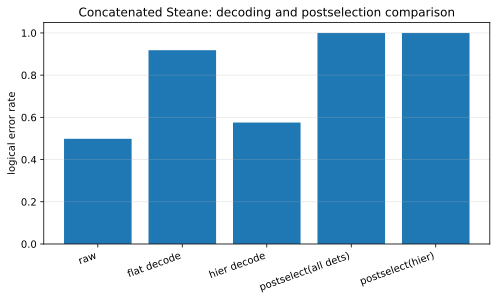

In [10]:
labels = [
    'raw',
    'flat decode',
    'hier decode',
    'postselect(all dets)',
    'postselect(hier)',
]
values = [
    raw_logical_error_rate,
    flat_decoded_error_rate,
    hier_decoded_error_rate,
    full_postselected_error_rate,
    hier_postselected_error_rate,
]

plt.figure(figsize=(8, 4))
plt.bar(labels, values)
plt.ylabel('logical error rate')
plt.title('Concatenated Steane: decoding and postselection comparison')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()